In [ ]:
#loading a dataset (fashion-MNIST)

In [1]:
#imports
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

#parameters of importing the dataset:

root is the path where the train/test data is stored,

train specifies training or test dataset,

download=True downloads the data from the internet if it’s not available at root.

transform and target_transform specify the feature and label transformations

In [ ]:
training_data = datasets.FashionMNIST(
    root="/Users/solomon/mnist-cnn/data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="/Users/solomon/mnist-cnn/data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

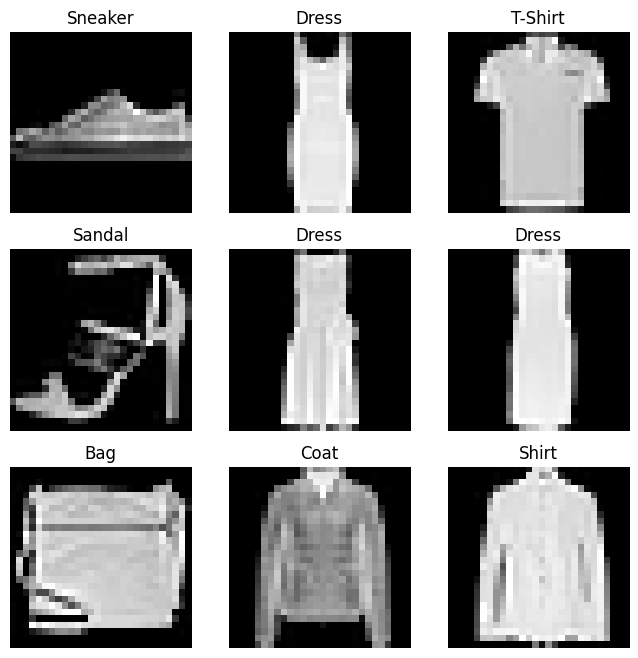

In [28]:
#iterating through the dataset and visualizing it
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
#making a custom dataset
import os
import pandas as pd
from torchvision.io import decode_image
# a custom Dataset class must implement three functions: __init__, __len__, and __getitem__
#example implementation:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [12]:
#the __init__ function:
#ran when instantiating the dataset object, includes the labels of each image, stored as an array, the directory of the images, and transforms (covered more in next section)

In [ ]:
#the __len__ function:
#v simple, returns number of samples in our dataset

In [ ]:
#the __getitem__ function:
#returns a sample from the dataset and index 'idx'
#based on the index, it identifies the image’s location on disk, converts that to a tensor using decode_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [14]:
#preparing data for training:
from torch.utils.data import DataLoader

#batch size is a paremter that determines how many samples will be passed per epoch (?) prior to reshuffling the data for the next epoch
#shuffling is determined with shuffle=True
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


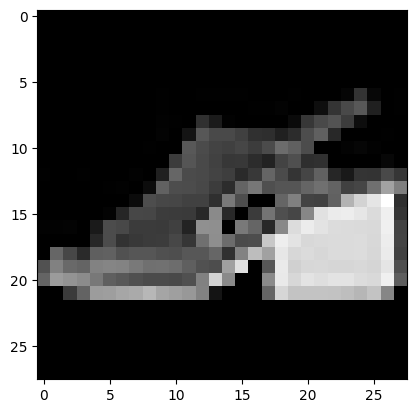

Label: 5
Label: Sandal


In [36]:
#iterating through the dataloader:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
#returns a batch of batchsize=64 features and labels
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
#the first image from the batch
label = train_labels[0]
#the first label from the batch
plt.imshow(img, cmap="grey")
plt.show()
print(f"Label: {label}")
print(f"Label: {labels_map[label.item()]}")